In [1]:
from llrf_app.app import LLRFApp
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import signal
import time

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

In [2]:
def calc_ps(wfm, title='', fullscale=32767, fs_mhz=115):
    fsdb = 20 * np.log10(fullscale / np.sqrt(2))
    f, pxx = signal.periodogram(
        wfm, fs_mhz, 'flattop', scaling='spectrum', nfft=8192)
    psd_dbfs = 10 * np.log10(pxx) - fsdb
    return f, psd_dbfs

def plot_ps(f, psd_dbfs, title='', annotate=False):
    fig, ax = plt.subplots()
    ax.set_xlabel('Freq [MHz]')
    ax.set_ylabel('Mag [dBFS]')
    ax.set_ylim(-120, 0)
    ax.set_title(title)
    if len(psd_dbfs.shape) == 1:
        ax.plot(f, psd_dbfs)
        if annotate:
            idx = np.argmax(psd_dbfs)
            pwr = psd_dbfs[idx]
            ax.annotate(
                f'{f[idx]:5.3f}  MHz\n {pwr:5.3f} dBFS',
                xy=(f[idx], pwr), xytext=(1, -20),
                arrowprops=dict(shrink=0.05))
    elif len(psd_dbfs.shape) == 2:   # plot psd array
        for ix, p in enumerate(psd_dbfs):
            ax.plot(f, p, label='adc' + str(ix))
        ax.legend()

## Plot raw DAC / ADC data

In [3]:
llrf = LLRFApp(addr='192.168.19.42:803', conf='LEMP', chan_keep=1)
llrf.write_reg('amp_setpoint', 30000)
llrf.write_reg('pulse_mode', 0)
time.sleep(0.5)
adc_wfm = llrf.read_adc_bufs()
dac_wfm = llrf.read_dac_bufs()

In [4]:
df_dac = pd.DataFrame(dac_wfm.T, columns=[f'dac{n}' for n in range(2)])
df_dac['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.dsp_clk_cycle
df_dac.set_index('Time [ns]', inplace=True)

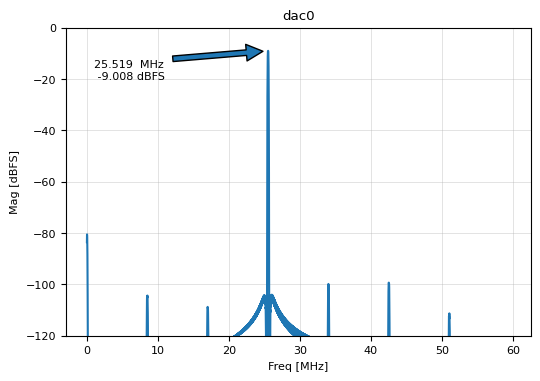

In [5]:
f, psd_dbfs = calc_ps(df_dac['dac0'], fs_mhz=1e3/llrf.dsp_clk_cycle)
plot_ps(f, psd_dbfs, title='dac0', annotate=True)

In [6]:
df = pd.DataFrame(adc_wfm.T, columns=[f'adc{n}' for n in range(8)])
df['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.dsp_clk_cycle
df.set_index('Time [ns]', inplace=True)

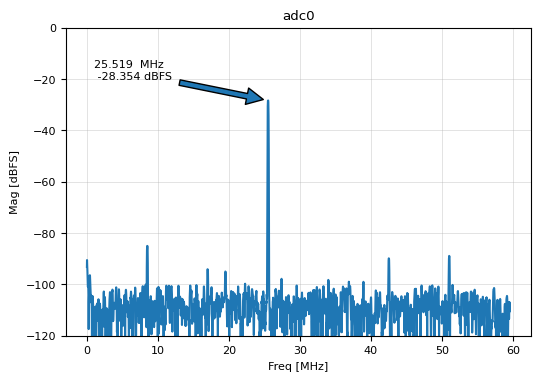

In [7]:
f, psd_dbfs = calc_ps(df['adc0'], fs_mhz=1e3/llrf.dsp_clk_cycle)
plot_ps(f, psd_dbfs, title='adc0', annotate=True)

## Plot circular buffer data (ADC0 only)

In [8]:
mp_traces = llrf.get_mp_wfm()

In [9]:
df_mp = pd.DataFrame(mp_traces.T, columns=['Amp [cnt]', 'Phase [deg]'])
df_mp['Time [ns]'] = np.arange(mp_traces.shape[-1]) * llrf.ts
df_mp.set_index('Time [ns]', inplace=True)

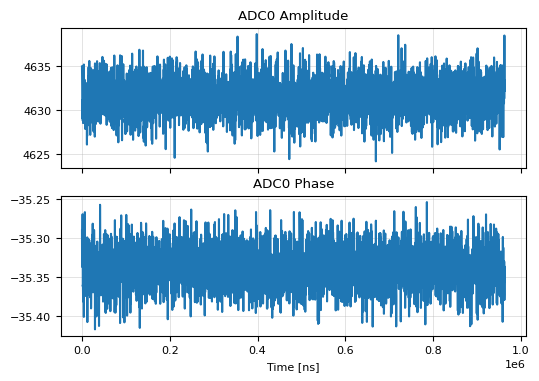

In [10]:
fig, axes = plt.subplots(2, sharex=True)
df_mp['Amp [cnt]'].plot(title='ADC0 Amplitude', ax=axes[0]);
df_mp['Phase [deg]'].plot(title='ADC0 Phase', ax=axes[1]);

# Pulse mode test

In [11]:
llrf = LLRFApp(addr='192.168.19.42:803', conf='LEMP', chan_keep=1)

# generate 4µs pulse
pulse_high_len = int(4000 / llrf.dsp_clk_cycle  / llrf.cic_base_period) + 1
llrf.reg_write([
    ('pulse_high_len', pulse_high_len),
    ('pulse_mode', 1)
])
time.sleep(0.5)

print(f'pulse_high_len: {pulse_high_len} counts')

pulse_high_len: 18 counts


In [12]:
def read_raw_adcs():
    adc_wfm = llrf.read_adc_bufs()
    df = pd.DataFrame(adc_wfm.T, columns=[f'adc{n}' for n in range(8)])
    df['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.dsp_clk_cycle
    df.set_index('Time [ns]', inplace=True)
    return df

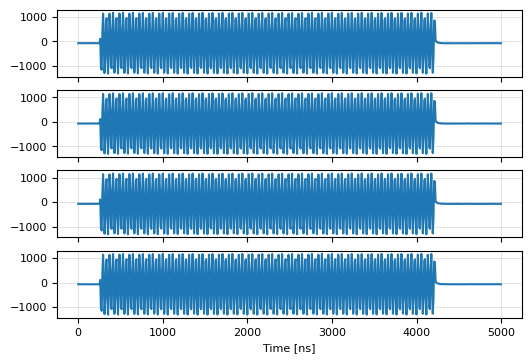

In [14]:
# read N times to check pulsing length certainty
N = 4
dfs = [read_raw_adcs()['adc0'] for _ in range(N)]

fig, axes = plt.subplots(N, sharex=True)
for df, ax in zip(dfs, axes):
    df.loc[:5000].plot(ax=ax);

# RAW ADC data demodulation demo

In [15]:
import sys
sys.path.append('../llrf_dsp/tests')
from llrf_dsp import DDC

In [16]:
ddc = DDC(num=3, den=14)
adc_data = read_raw_adcs()['adc0'].values
ddc_data = ddc.calc_ddc_raw(adc_data)

In [17]:
amp, phs = np.abs(ddc_data), np.angle(ddc_data, deg=True)

df = pd.DataFrame(np.array([amp, phs]).T, columns=['Amp [cnt]', 'Phase [deg]'])
df['Time [ns]'] = np.arange(ddc_data.shape[-1]) * llrf.dsp_clk_cycle
df.set_index('Time [ns]', inplace=True)

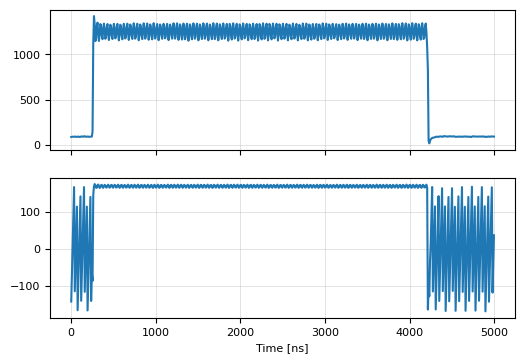

In [18]:
df = df.loc[:5000]
fig, axes = plt.subplots(2, sharex=True)
df['Amp [cnt]'].plot(ax=axes[0])
df['Phase [deg]'].plot(ax=axes[1]);

## Plot circular buffer data (ADC0 only)

In [19]:
mp_traces = llrf.get_mp_wfm()

In [20]:
df_mp = pd.DataFrame(mp_traces.T, columns=['Amp [cnt]', 'Phase [deg]'])
df_mp['Time [ns]'] = np.arange(mp_traces.shape[-1]) * llrf.ts
df_mp.set_index('Time [ns]', inplace=True)

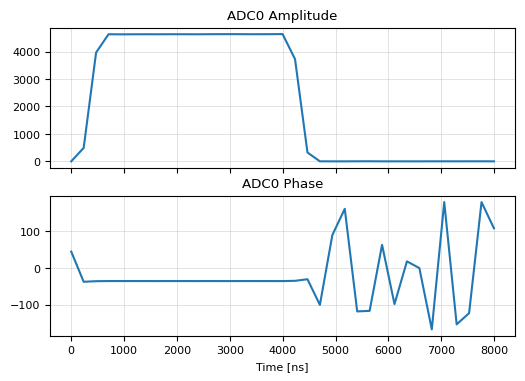

In [21]:
fig, axes = plt.subplots(2, sharex=True)
df_mp['Amp [cnt]'].loc[:8000].plot(title='ADC0 Amplitude', ax=axes[0]);
df_mp['Phase [deg]'].loc[:8000].plot(title='ADC0 Phase', ax=axes[1]);